# Chapter 11: Computation of the Fundamental Matrix F

Source orientation: printed pages 279-309; PDF pages 297-327. This notebook uses the source span for section names and concept coverage only; the prose, data, code, and figures here are original.

Chapter 11 is about turning noisy image correspondences into a usable rank-two fundamental matrix. The chapter moves from the basic epipolar equations to normalized linear estimation, algebraic and geometric error criteria, robust automatic estimation, degeneracies, envelopes of epipolar lines, and rectification. The notebook follows that route with synthetic measurements whose ground truth is known, so every visual has a numerical check beside it.


## Chapter Goal

By the end of this notebook you should be able to inspect a fundamental-matrix estimate as a computation, not just as a 3 by 3 array:

- form the homogeneous linear equations behind the eight-point algorithm;
- see why isotropic normalization changes the conditioning of the design matrix;
- enforce the rank-two singularity constraint and verify it numerically;
- use Sampson distance and RANSAC to separate inlier and outlier correspondences;
- recognize why planar correspondences make fundamental-matrix estimation ambiguous.


## Translation Guide

| Book concept | Computational representation in this notebook | Inspection target |
| --- | --- | --- |
| Epipolar equation | rows of a design matrix `A` built from `x2.T @ F @ x1 = 0` | each correspondence contributes one linear equation in the entries of `F` |
| Normalized eight-point algorithm | centering and scaling points, SVD null vector, denormalization | the condition number of `A` falls after normalization |
| Singularity constraint | SVD of the preliminary matrix and zeroing the smallest singular value | the post-enforcement matrix has numerical rank two |
| Geometric error | Sampson approximation to image correction error | inlier residuals are visibly and numerically smaller than outlier residuals |
| Robust computation | `cv2.findFundamentalMat(..., cv2.FM_RANSAC, ...)` | inlier mask, epiline overlay, and residual separation agree |
| Degeneracy | rank and nullspace of the design matrix for planar data | planar correspondences leave multiple low-residual `F` candidates |


## Route Through The Chapter

The section map is: basic equations and the singularity constraint; the normalized eight-point algorithm; algebraic minimization; geometric distance and the Sampson approximation; experimental recommendations; automatic robust computation; special cases and degeneracies; geometric interpretation, epipolar-line envelopes, and rectification.

The visual storyboard implements the approved pass:

1. `figures/eight-point-normalization-pipeline.png` checks raw versus normalized coordinates and the design-matrix conditioning.
2. `figures/fundamental-rank-enforcement.png` checks the singular spectrum before and after enforcing rank two.
3. `figures/ransac-epiline-inliers.png` checks robust inlier/outlier separation with epilines and Sampson residuals.
4. `figures/planar-degeneracy-warning.png` and `checks/fundamental-estimation-invariants.json` compare a general scene with planar correspondences.


In [1]:
from pathlib import Path
import sys

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the MVG book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

TOPIC = "chapter-11"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / TOPIC
(ARTIFACT_ROOT / "figures").mkdir(parents=True, exist_ok=True)
(ARTIFACT_ROOT / "checks").mkdir(parents=True, exist_ok=True)


In [2]:
import json

import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy import linalg

from utils.artifacts import assert_artifacts, display_artifact, save_json, save_matplotlib
from utils.cameras import project_points, synthetic_cameras
from utils.epipolar import enforce_rank2, fundamental_from_cameras, sampson_errors
from utils.projective import homogenize

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.2,
})

SEED = 11011
rng = np.random.default_rng(SEED)
artifact_paths = []
invariants = {"seed": SEED, "source_span": "printed pages 279-309; PDF pages 297-327"}


## Library Routing

This is a camera/projective-geometry chapter, so the core tools are OpenCV for the robust fundamental-matrix estimator, NumPy/SciPy SVD for transparent linear algebra, and Matplotlib for durable static overlays. The notebook uses the course artifact helpers only for path discipline and inline display; the estimation steps are visible in the notebook cells.


In [3]:
def normalize_points(points):
    """Return homogeneous normalized points and the similarity transform."""
    pts = np.asarray(points, dtype=float)
    centroid = pts.mean(axis=0)
    shifted = pts - centroid
    rms = np.sqrt(np.mean(np.sum(shifted**2, axis=1)))
    scale = np.sqrt(2.0) / max(rms, 1e-12)
    T = np.array([
        [scale, 0.0, -scale * centroid[0]],
        [0.0, scale, -scale * centroid[1]],
        [0.0, 0.0, 1.0],
    ])
    normalized = (T @ homogenize(pts).T).T
    return normalized, T


def design_matrix(points1_h, points2_h):
    rows = []
    for a, b in zip(points1_h, points2_h):
        x, y, w = a
        xp, yp, wp = b
        rows.append([xp*x, xp*y, xp*w, yp*x, yp*y, yp*w, wp*x, wp*y, wp*w])
    return np.asarray(rows, dtype=float)


def eight_point_diagnostics(points1, points2):
    x1_raw = homogenize(points1)
    x2_raw = homogenize(points2)
    x1_norm, T1 = normalize_points(points1)
    x2_norm, T2 = normalize_points(points2)
    A_raw = design_matrix(x1_raw, x2_raw)
    A_norm = design_matrix(x1_norm, x2_norm)
    _, _, vt = linalg.svd(A_norm, full_matrices=False)
    F_norm_pre = vt[-1].reshape(3, 3)
    F_norm_rank2 = enforce_rank2(F_norm_pre)
    F = enforce_rank2(T2.T @ F_norm_rank2 @ T1)
    return {
        "x1_raw": x1_raw,
        "x2_raw": x2_raw,
        "x1_norm": x1_norm,
        "x2_norm": x2_norm,
        "A_raw": A_raw,
        "A_norm": A_norm,
        "F_norm_pre": F_norm_pre,
        "F_norm_rank2": F_norm_rank2,
        "F": F,
        "raw_condition": float(np.linalg.cond(A_raw)),
        "normalized_condition": float(np.linalg.cond(A_norm)),
    }


def clip_line_to_image(line, width=640, height=480):
    a, b, c = line
    candidates = []
    if abs(b) > 1e-12:
        candidates.extend([(0.0, -c / b), (width, -(a * width + c) / b)])
    if abs(a) > 1e-12:
        candidates.extend([(-c / a, 0.0), (-(b * height + c) / a, height)])
    inside = [(x, y) for x, y in candidates if -10 <= x <= width + 10 and -10 <= y <= height + 10]
    if len(inside) >= 2:
        return inside[0], inside[1]
    return None


def make_measurements(n=80, outliers=16, noise=0.55):
    K, P1, P2 = synthetic_cameras()
    points3d = np.column_stack([
        rng.uniform(-1.2, 1.2, n),
        rng.uniform(-0.8, 0.8, n),
        rng.uniform(2.4, 4.4, n),
    ])
    x1_clean = project_points(P1, points3d)
    x2_clean = project_points(P2, points3d)
    x1_noisy = x1_clean + rng.normal(0.0, noise, x1_clean.shape)
    x2_noisy = x2_clean + rng.normal(0.0, noise, x2_clean.shape)
    outlier_index = rng.choice(n, outliers, replace=False)
    x2_mixed = x2_noisy.copy()
    x2_mixed[outlier_index] = np.column_stack([
        rng.uniform(40.0, 600.0, outliers),
        rng.uniform(35.0, 445.0, outliers),
    ])
    truth = np.ones(n, dtype=bool)
    truth[outlier_index] = False
    return K, P1, P2, points3d, x1_clean, x2_clean, x1_noisy, x2_noisy, x2_mixed, truth


## 1. Normalized Eight-Point Pipeline

The eight-point algorithm solves a homogeneous linear system. Raw pixel coordinates can put columns of the design matrix on very different scales, so the SVD may spend its numerical precision on units rather than geometry. The normalization step recenters each image's points and scales their root-mean-square radius to roughly `sqrt(2)`.

Inspect the next figure from left to right: the raw image measurements, the normalized measurements, the normalized design matrix, and the condition number change. The invariant is simple: normalization should improve conditioning before we trust the null vector as an estimate of `F`.


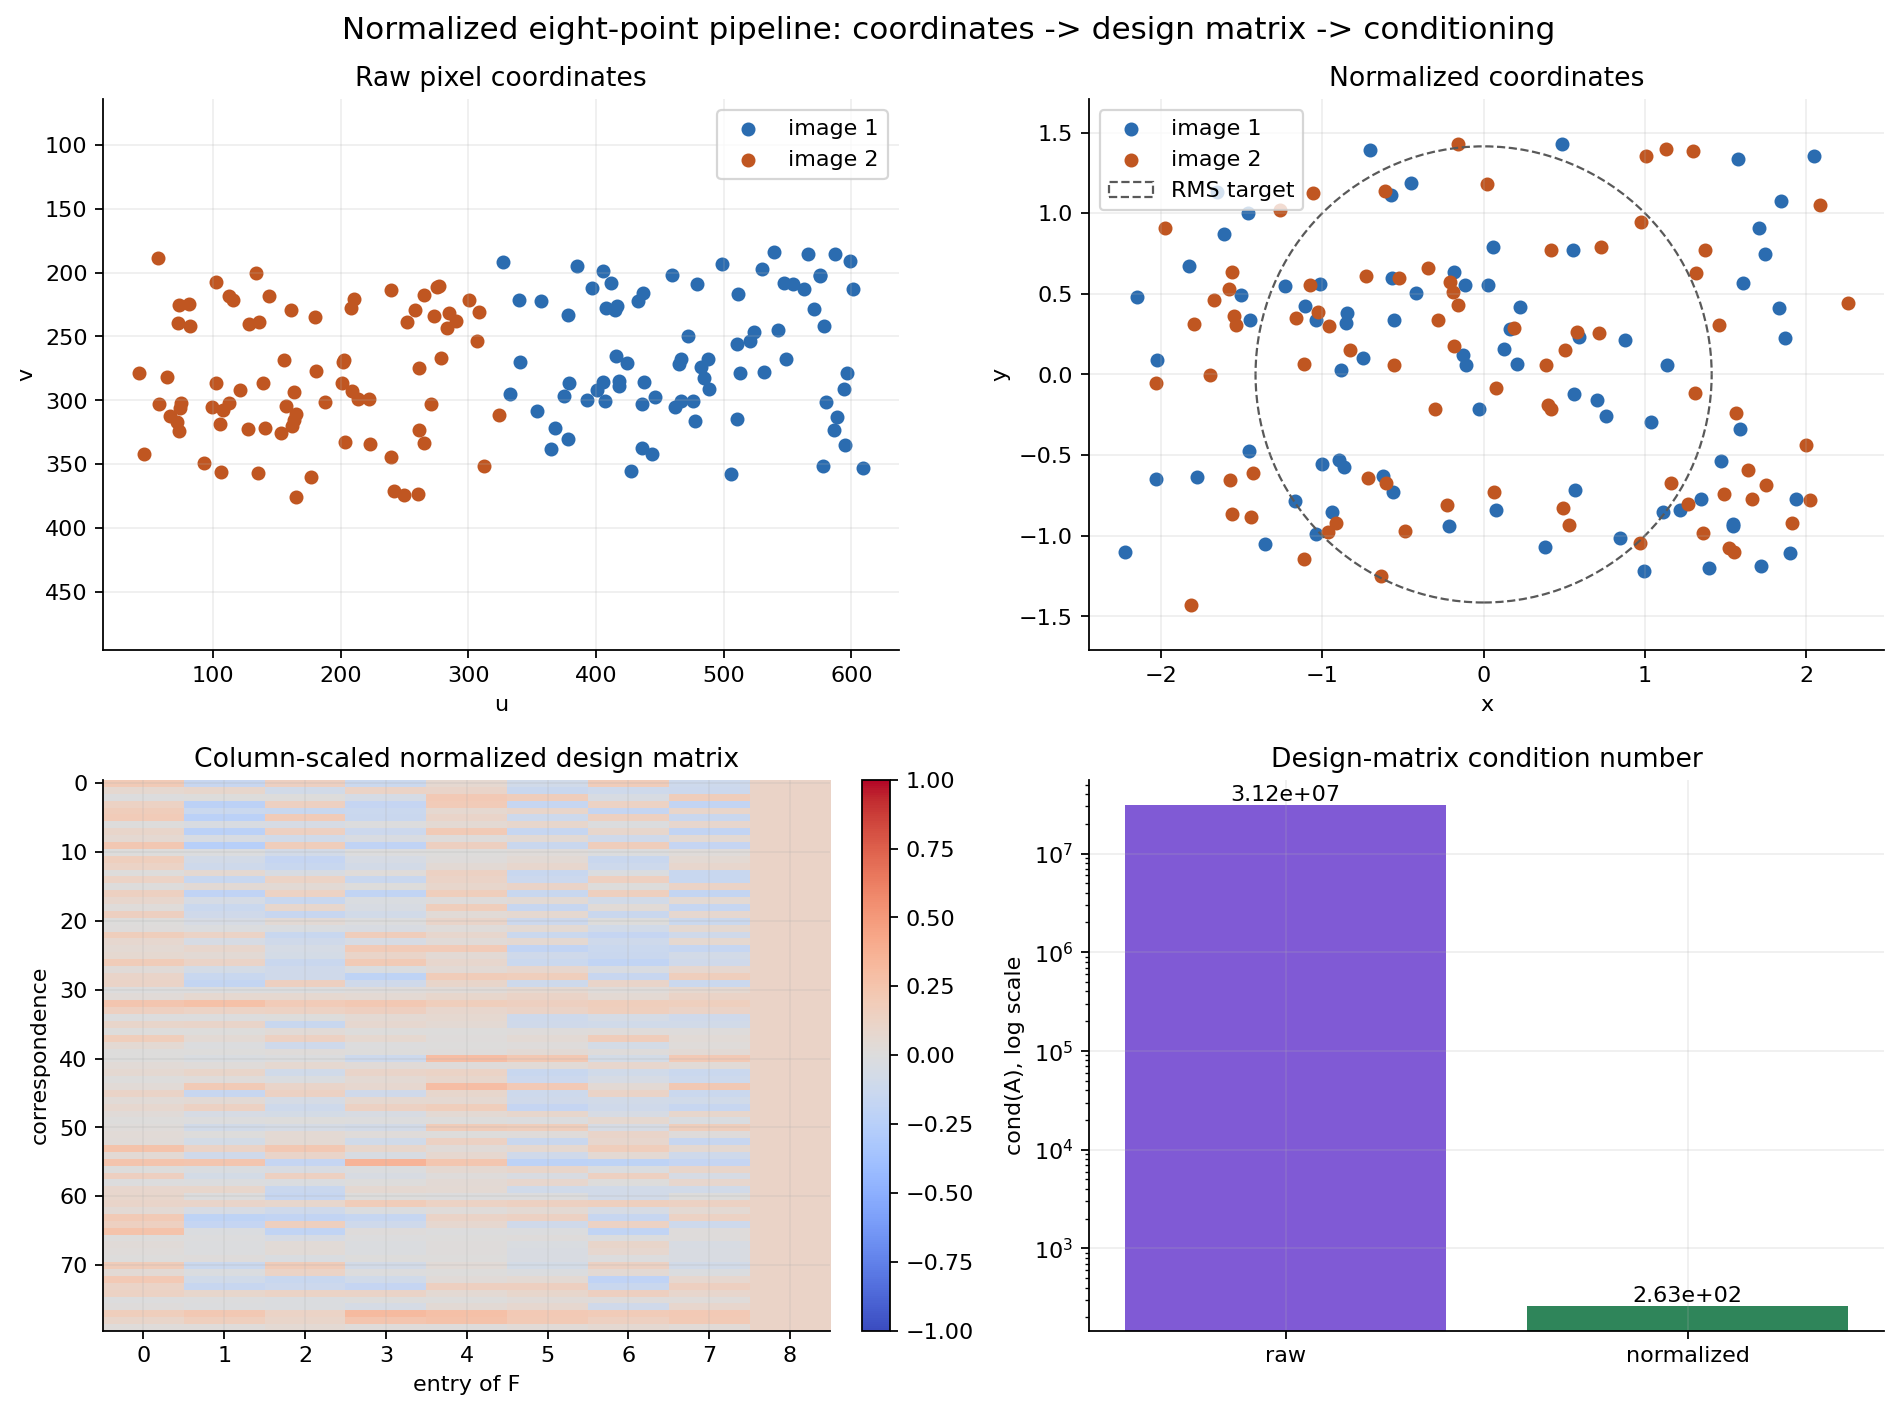

{'raw_design_matrix_condition': 31213745.466690883,
 'normalized_design_matrix_condition': 263.46190799347096,
 'conditioning_improvement_factor': 118475.36406463895}

In [4]:
K, P1, P2, points3d, x1_clean, x2_clean, x1_noisy, x2_noisy, x2_mixed, true_inlier_mask = make_measurements()
F_true = fundamental_from_cameras(P1, P2)
diag = eight_point_diagnostics(x1_noisy, x2_noisy)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
ax = axes[0, 0]
ax.scatter(x1_noisy[:, 0], x1_noisy[:, 1], s=28, label="image 1", color="#2b6cb0")
ax.scatter(x2_noisy[:, 0], x2_noisy[:, 1], s=28, label="image 2", color="#c05621")
ax.set_title("Raw pixel coordinates")
ax.set_xlabel("u")
ax.set_ylabel("v")
ax.invert_yaxis()
ax.axis("equal")
ax.legend(loc="best")

ax = axes[0, 1]
ax.scatter(diag["x1_norm"][:, 0], diag["x1_norm"][:, 1], s=28, label="image 1", color="#2b6cb0")
ax.scatter(diag["x2_norm"][:, 0], diag["x2_norm"][:, 1], s=28, label="image 2", color="#c05621")
unit = plt.Circle((0, 0), np.sqrt(2), fill=False, linestyle="--", color="0.35", label="RMS target")
ax.add_patch(unit)
ax.set_title("Normalized coordinates")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.axis("equal")
ax.legend(loc="best")

ax = axes[1, 0]
scaled_A = diag["A_norm"] / np.maximum(np.linalg.norm(diag["A_norm"], axis=0, keepdims=True), 1e-12)
im = ax.imshow(scaled_A, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
ax.set_title("Column-scaled normalized design matrix")
ax.set_xlabel("entry of F")
ax.set_ylabel("correspondence")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1, 1]
conds = [diag["raw_condition"], diag["normalized_condition"]]
ax.bar(["raw", "normalized"], conds, color=["#805ad5", "#2f855a"])
ax.set_yscale("log")
ax.set_title("Design-matrix condition number")
ax.set_ylabel("cond(A), log scale")
for i, value in enumerate(conds):
    ax.text(i, value, f"{value:.2e}", ha="center", va="bottom")
fig.suptitle("Normalized eight-point pipeline: coordinates -> design matrix -> conditioning", fontsize=14)
fig.tight_layout()

normalization_path = save_matplotlib(fig, TOPIC, "figures", "eight-point-normalization-pipeline.png")
plt.close(fig)
artifact_paths.append(normalization_path)
display_artifact(normalization_path)

invariants["normalization"] = {
    "raw_design_matrix_condition": diag["raw_condition"],
    "normalized_design_matrix_condition": diag["normalized_condition"],
    "conditioning_improvement_factor": diag["raw_condition"] / diag["normalized_condition"],
}
invariants["normalization"]


## 2. Rank Enforcement Singular Spectrum

The linear null vector gives a 3 by 3 matrix, but the fundamental matrix must be singular: its epipolar lines all pass through an epipole. The standard enforcement step takes the preliminary matrix, sets its smallest singular value to zero, and reconstructs it.

The visual below shows both the spectrum and the matrix entries before/after enforcement. The check is deliberately blunt: the smallest post-enforcement singular value should be zero to numerical precision.


C:\Users\rahul\AppData\Local\Temp\ipykernel_24672\3742526513.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


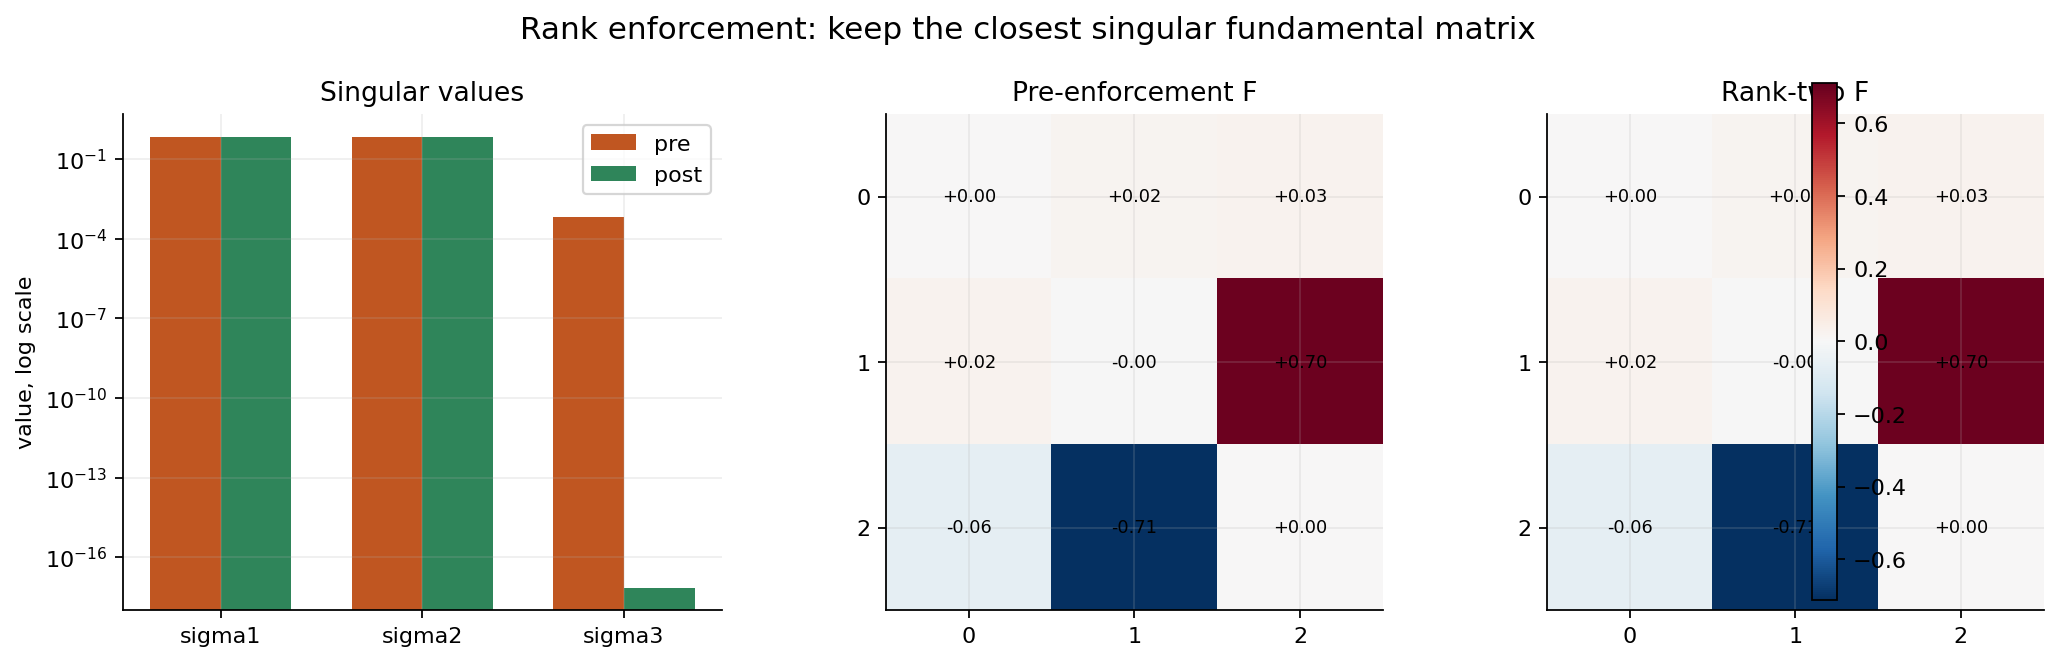

{'pre_singular_values': [0.7152160566280656,
  0.6989030760786668,
  0.0006946863875366062],
 'post_singular_values': [0.7152162292058923,
  0.6989032447202577,
  7.042145430106268e-18],
 'post_smallest_singular_value': 7.042145430106268e-18,
 'post_rank_tolerance_1e_minus_10': 2}

In [5]:
F_pre = diag["F_norm_pre"]
F_post = diag["F_norm_rank2"]
rank_singular_pre = linalg.svd(F_pre, compute_uv=False)
rank_singular_post = linalg.svd(F_post, compute_uv=False)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
ax = axes[0]
x = np.arange(3)
width = 0.35
ax.bar(x - width/2, rank_singular_pre, width, label="pre", color="#c05621")
ax.bar(x + width/2, rank_singular_post, width, label="post", color="#2f855a")
ax.set_xticks(x, ["sigma1", "sigma2", "sigma3"])
ax.set_yscale("log")
ax.set_title("Singular values")
ax.set_ylabel("value, log scale")
ax.legend()

limit = max(abs(F_pre).max(), abs(F_post).max())
for ax, matrix, title in zip(axes[1:], [F_pre, F_post], ["Pre-enforcement F", "Rank-two F"]):
    im = ax.imshow(matrix, cmap="RdBu_r", vmin=-limit, vmax=limit)
    for (i, j), value in np.ndenumerate(matrix):
        ax.text(j, i, f"{value:+.2f}", ha="center", va="center", fontsize=8)
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_title(title)
fig.colorbar(im, ax=axes[1:].ravel().tolist(), fraction=0.046, pad=0.04)
fig.suptitle("Rank enforcement: keep the closest singular fundamental matrix", fontsize=14)
fig.tight_layout()

rank_path = save_matplotlib(fig, TOPIC, "figures", "fundamental-rank-enforcement.png")
plt.close(fig)
artifact_paths.append(rank_path)
display_artifact(rank_path)

invariants["rank_enforcement"] = {
    "pre_singular_values": rank_singular_pre.tolist(),
    "post_singular_values": rank_singular_post.tolist(),
    "post_smallest_singular_value": float(rank_singular_post[-1]),
    "post_rank_tolerance_1e_minus_10": int(np.linalg.matrix_rank(F_post, tol=1e-10)),
}
invariants["rank_enforcement"]


## 3. Robust Inlier Epiline Overlay

Automatic estimation adds a sampling layer around the same epipolar constraint. Here OpenCV's RANSAC estimator receives a mixed correspondence set: most matches come from the two synthetic cameras, while a controlled set of false matches has been injected. The figure shows the recovered inliers and the epipolar lines in the second image induced by their first-image points.

The visual target is separation: inliers should sit near their epilines, outliers should not, and the median Sampson distance should confirm that visual judgment.


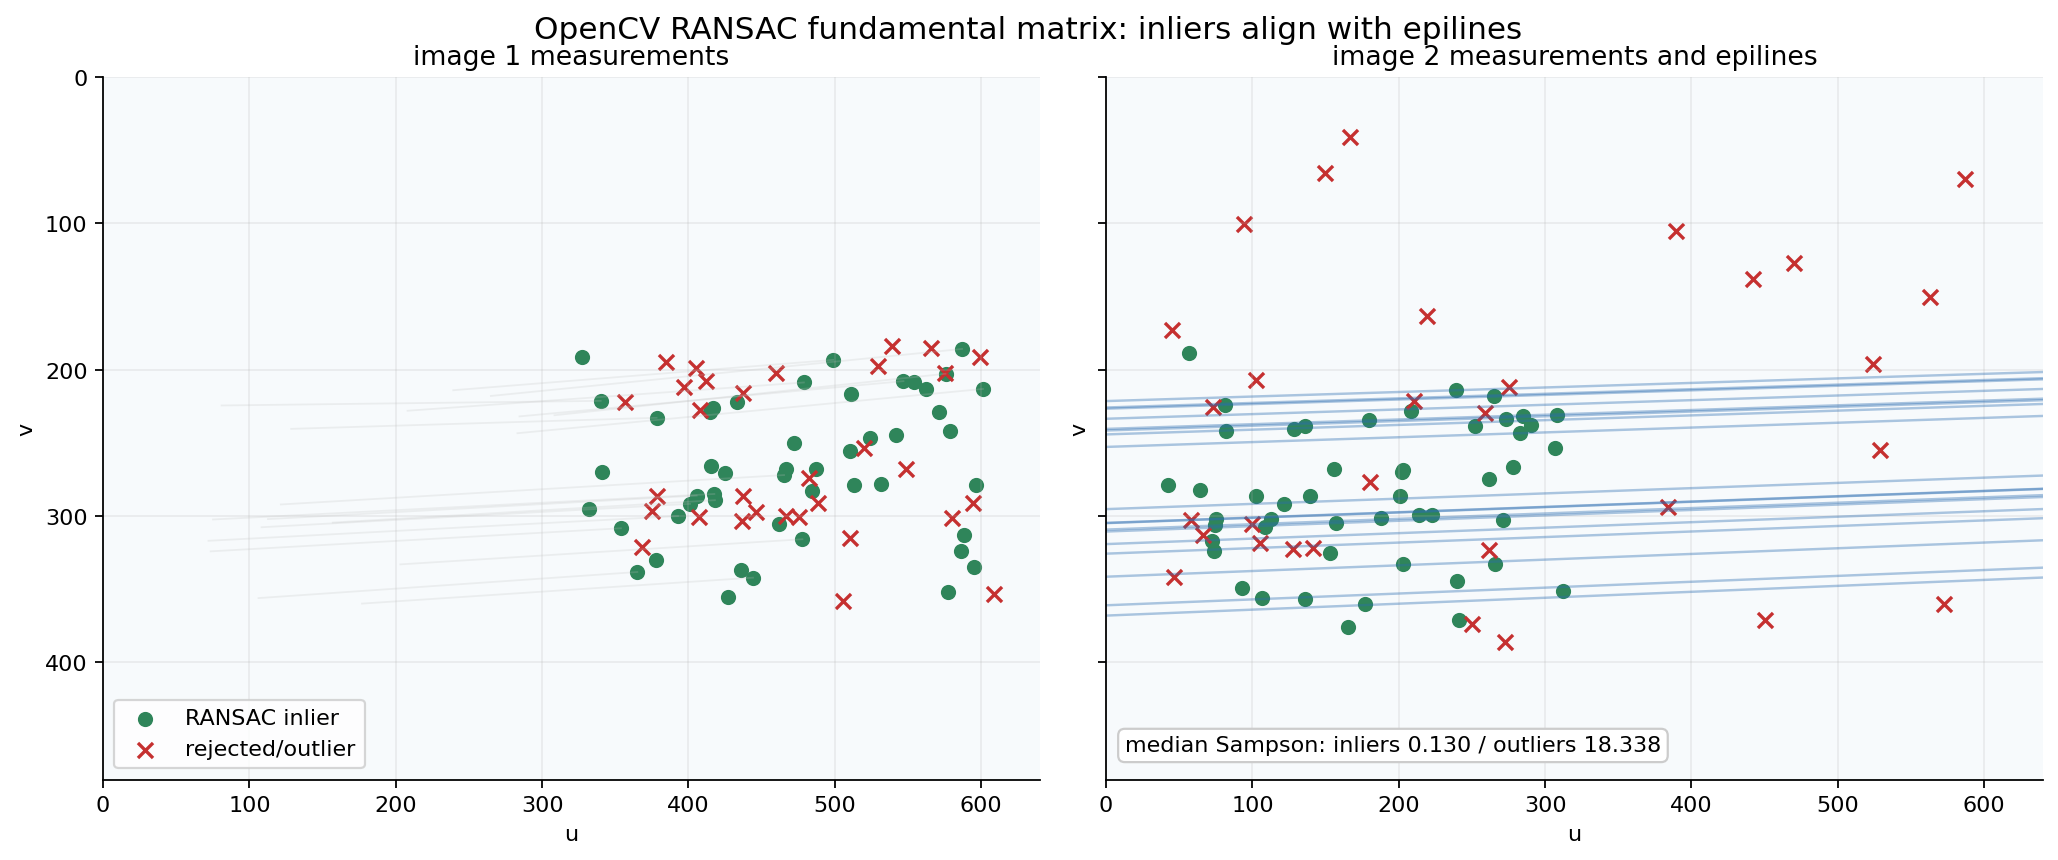

{'opencv_method': 'cv2.findFundamentalMat with cv2.FM_RANSAC',
 'threshold_pixels': 1.4,
 'estimated_inliers': 49,
 'estimated_outliers': 31,
 'median_sampson_inliers': 0.13044456112975727,
 'median_sampson_outliers': 18.337786996249733,
 'median_separation_factor': 140.57916127302974}

In [6]:
F_cv, cv_mask = cv2.findFundamentalMat(
    x1_noisy.astype(np.float32),
    x2_mixed.astype(np.float32),
    cv2.FM_RANSAC,
    1.4,
    0.995,
    5000,
)
if F_cv is None or cv_mask is None:
    raise RuntimeError("OpenCV RANSAC failed to estimate a fundamental matrix")
F_ransac = enforce_rank2(F_cv)
ransac_inlier_mask = cv_mask.ravel().astype(bool)
ransac_errors = sampson_errors(F_ransac, x1_noisy, x2_mixed)
inlier_median = float(np.median(ransac_errors[ransac_inlier_mask]))
outlier_median = float(np.median(ransac_errors[~ransac_inlier_mask]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharex=True, sharey=True)
for ax, pts, title in zip(axes, [x1_noisy, x2_mixed], ["image 1 measurements", "image 2 measurements and epilines"]):
    ax.set_facecolor("#f7fafc")
    ax.set_xlim(0, 640)
    ax.set_ylim(480, 0)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("u")
    ax.set_ylabel("v")
    ax.scatter(pts[ransac_inlier_mask, 0], pts[ransac_inlier_mask, 1], s=34, color="#2f855a", label="RANSAC inlier")
    ax.scatter(pts[~ransac_inlier_mask, 0], pts[~ransac_inlier_mask, 1], s=46, marker="x", color="#c53030", label="rejected/outlier")

sample_inliers = np.flatnonzero(ransac_inlier_mask)[:18]
for idx in sample_inliers:
    line = F_ransac @ homogenize(x1_noisy[[idx]])[0]
    clipped = clip_line_to_image(line)
    if clipped is not None:
        (x0, y0), (x1, y1) = clipped
        axes[1].plot([x0, x1], [y0, y1], color="#2b6cb0", alpha=0.38, linewidth=1.1)
        axes[0].plot([x1_noisy[idx, 0], x2_mixed[idx, 0]], [x1_noisy[idx, 1], x2_mixed[idx, 1]], color="0.75", alpha=0.22, linewidth=0.8)
axes[0].legend(loc="lower left")
axes[1].text(
    0.02,
    0.04,
    f"median Sampson: inliers {inlier_median:.3f} / outliers {outlier_median:.3f}",
    transform=axes[1].transAxes,
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": "0.8"},
)
fig.suptitle("OpenCV RANSAC fundamental matrix: inliers align with epilines", fontsize=14)
fig.tight_layout()

ransac_path = save_matplotlib(fig, TOPIC, "figures", "ransac-epiline-inliers.png")
plt.close(fig)
artifact_paths.append(ransac_path)
display_artifact(ransac_path)

invariants["ransac"] = {
    "opencv_method": "cv2.findFundamentalMat with cv2.FM_RANSAC",
    "threshold_pixels": 1.4,
    "estimated_inliers": int(ransac_inlier_mask.sum()),
    "estimated_outliers": int((~ransac_inlier_mask).sum()),
    "median_sampson_inliers": inlier_median,
    "median_sampson_outliers": outlier_median,
    "median_separation_factor": outlier_median / max(inlier_median, 1e-12),
}
invariants["ransac"]


## 4. Degenerate Planar Warning

A planar correspondence set can be explained by a homography, so it does not pin down a unique fundamental matrix in the same way a general 3D scene does. The warning sign appears directly in the design matrix: for exact general 3D correspondences there is one numerical null direction, while planar correspondences leave a larger nullspace.

The next figure compares a general scene with a coplanar scene using the same cameras. The point is not that the planar data look suspicious in one image; the point is that the algebraic fit has too much freedom, so several different matrices can score almost equally well.


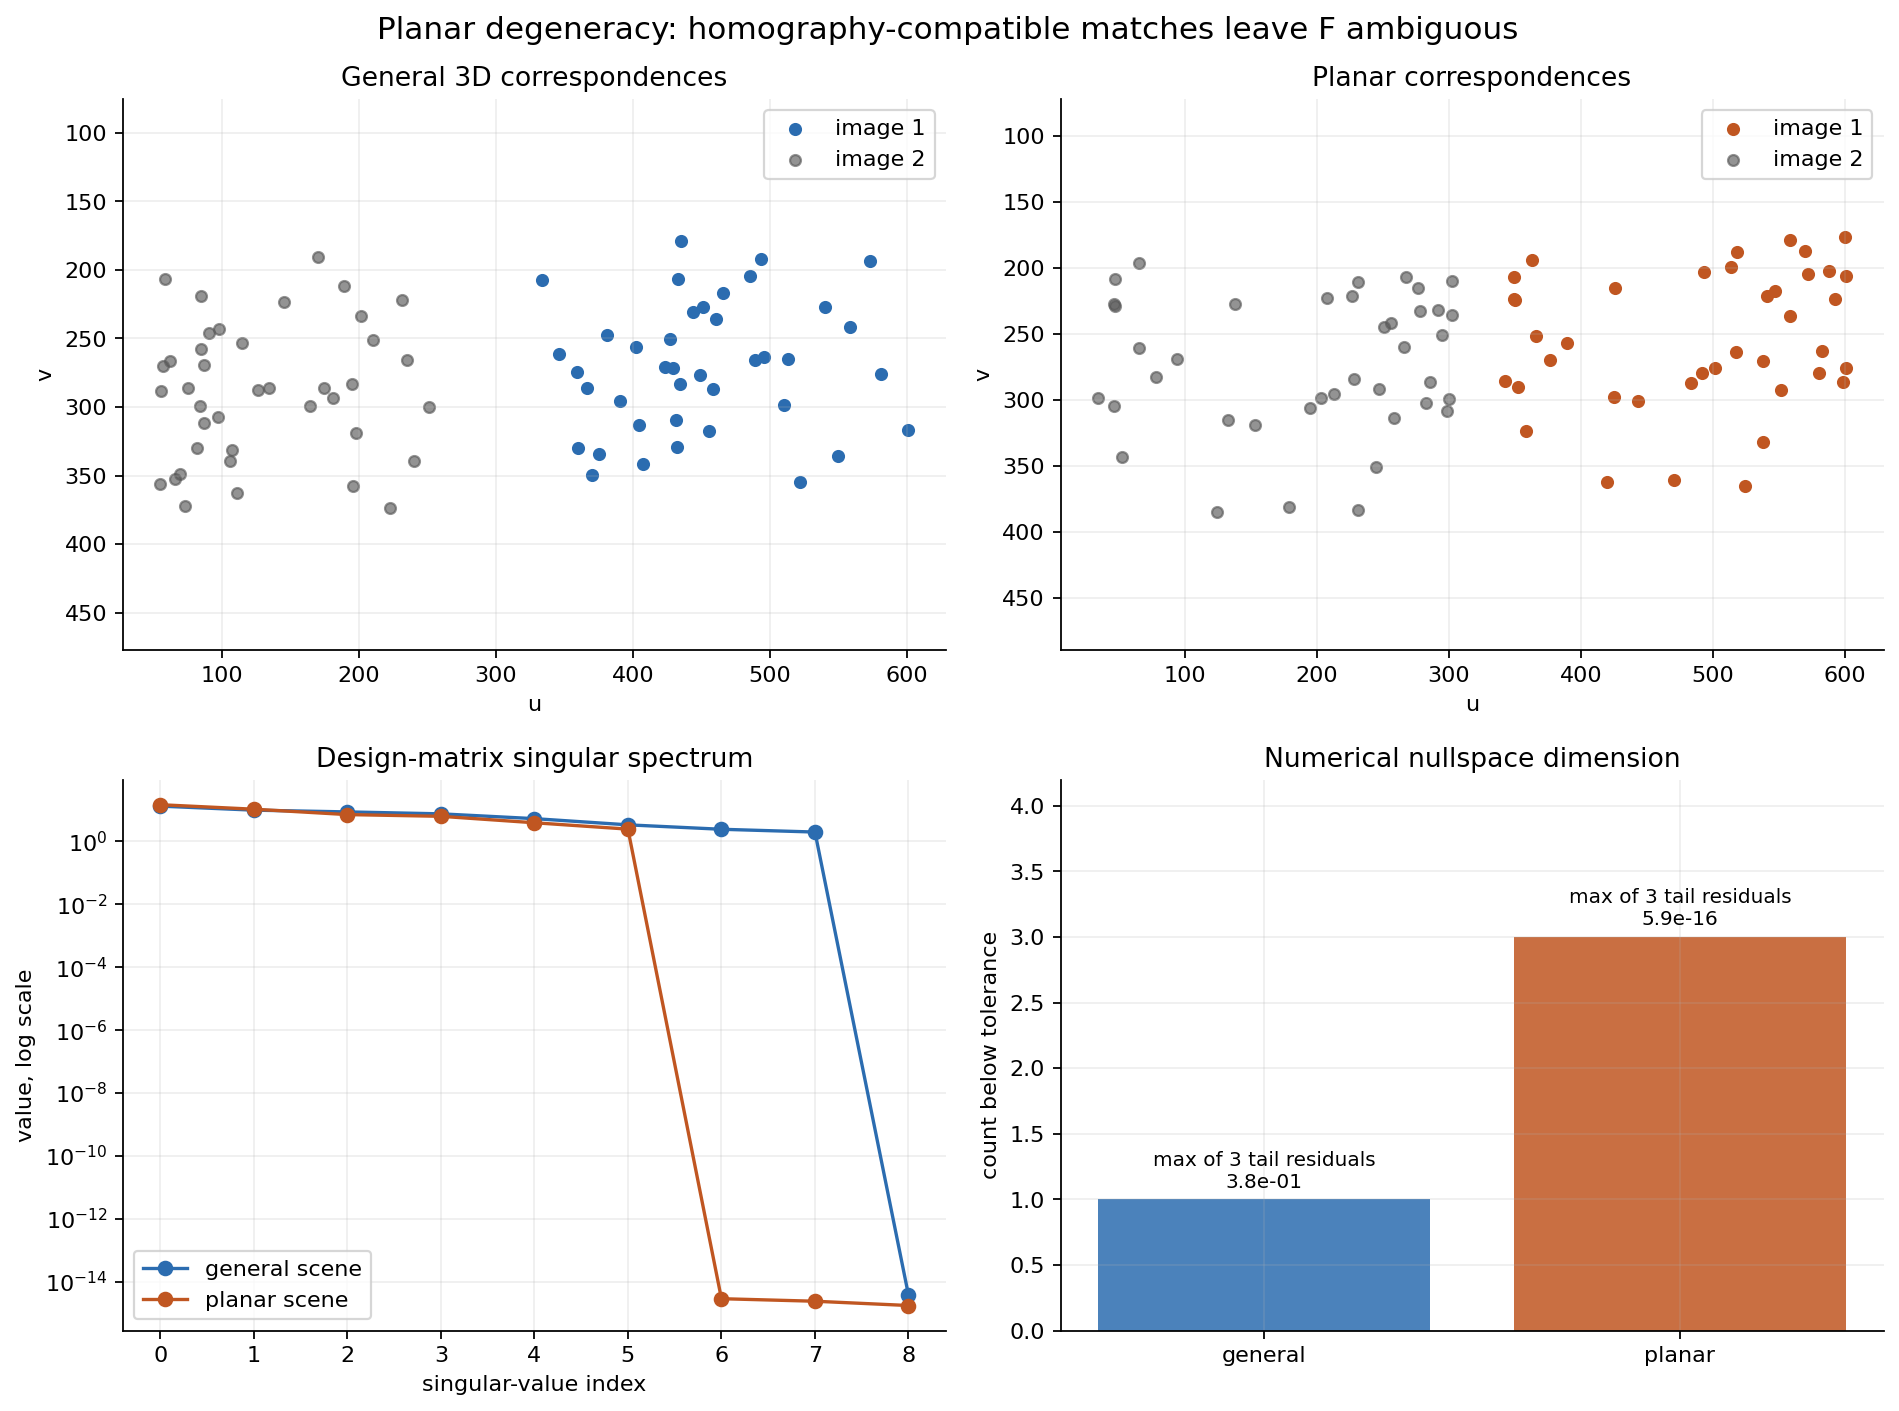

{'general_design_matrix_nullity': 1,
 'planar_design_matrix_nullity': 3,
 'general_singular_tail': [3.3197687009476655,
  2.4012969587052853,
  1.9595594672160404,
  3.71503188978141e-15],
 'planar_singular_tail': [2.4275941632351823,
  2.8522908331499294e-15,
  2.3695750933381172e-15,
  1.73200768025295e-15],
 'general_tail_candidate_residuals': [0.3796783863971998,
  0.30983355634743676,
  6.244752770250552e-16],
 'planar_tail_candidate_residuals': [5.933652015403066e-16,
  4.005145550092132e-16,
  3.4362590835148243e-16]}

In [7]:
def degeneracy_case(planar=False, n=40):
    if planar:
        pts3d = np.column_stack([
            rng.uniform(-1.2, 1.2, n),
            rng.uniform(-0.9, 0.9, n),
            np.full(n, 3.2),
        ])
    else:
        pts3d = np.column_stack([
            rng.uniform(-1.1, 1.1, n),
            rng.uniform(-0.8, 0.8, n),
            rng.uniform(2.4, 4.8, n),
        ])
    p1 = project_points(P1, pts3d)
    p2 = project_points(P2, pts3d)
    p1n, _ = normalize_points(p1)
    p2n, _ = normalize_points(p2)
    A = design_matrix(p1n, p2n)
    u, s, vt = linalg.svd(A, full_matrices=False)
    tol = 1e-10 * s[0]
    nullity = int(np.sum(s < tol))
    candidate_residuals = []
    for row in vt[-3:]:
        candidate = row.reshape(3, 3)
        residual = np.linalg.norm(A @ candidate.reshape(-1)) / np.sqrt(len(A))
        candidate_residuals.append(float(residual))
    return {"points3d": pts3d, "p1": p1, "p2": p2, "A": A, "singular_values": s, "nullity": nullity, "candidate_residuals": candidate_residuals}

general_case = degeneracy_case(planar=False)
planar_case = degeneracy_case(planar=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, case, title, color in [
    (axes[0, 0], general_case, "General 3D correspondences", "#2b6cb0"),
    (axes[0, 1], planar_case, "Planar correspondences", "#c05621"),
]:
    ax.scatter(case["p1"][:, 0], case["p1"][:, 1], s=24, color=color, label="image 1")
    ax.scatter(case["p2"][:, 0], case["p2"][:, 1], s=24, color="0.35", alpha=0.65, label="image 2")
    ax.set_title(title)
    ax.set_xlabel("u")
    ax.set_ylabel("v")
    ax.invert_yaxis()
    ax.axis("equal")
    ax.legend(loc="best")

ax = axes[1, 0]
ax.semilogy(general_case["singular_values"], marker="o", label="general scene", color="#2b6cb0")
ax.semilogy(planar_case["singular_values"], marker="o", label="planar scene", color="#c05621")
ax.set_title("Design-matrix singular spectrum")
ax.set_xlabel("singular-value index")
ax.set_ylabel("value, log scale")
ax.legend()

ax = axes[1, 1]
labels = ["general", "planar"]
nullities = [general_case["nullity"], planar_case["nullity"]]
residual_widths = [max(general_case["candidate_residuals"]), max(planar_case["candidate_residuals"])]
ax.bar(labels, nullities, color=["#2b6cb0", "#c05621"], alpha=0.85)
ax.set_title("Numerical nullspace dimension")
ax.set_ylabel("count below tolerance")
for i, (nullity, width) in enumerate(zip(nullities, residual_widths)):
    ax.text(i, nullity + 0.06, f"max of 3 tail residuals\n{width:.1e}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, max(nullities) + 1.2)
fig.suptitle("Planar degeneracy: homography-compatible matches leave F ambiguous", fontsize=14)
fig.tight_layout()

planar_path = save_matplotlib(fig, TOPIC, "figures", "planar-degeneracy-warning.png")
plt.close(fig)
artifact_paths.append(planar_path)
display_artifact(planar_path)

invariants["degeneracy"] = {
    "general_design_matrix_nullity": general_case["nullity"],
    "planar_design_matrix_nullity": planar_case["nullity"],
    "general_singular_tail": general_case["singular_values"][-4:].tolist(),
    "planar_singular_tail": planar_case["singular_values"][-4:].tolist(),
    "general_tail_candidate_residuals": general_case["candidate_residuals"],
    "planar_tail_candidate_residuals": planar_case["candidate_residuals"],
}
invariants["degeneracy"]


## Applied Lab: Replacing The Synthetic Matches

To use this notebook with a real image pair, keep the artifact contract unchanged:

1. collect tentative matches as two `N x 2` arrays in pixel coordinates;
2. run the normalization diagnostic before fitting so the design matrix is visible;
3. run `cv2.findFundamentalMat` with a RANSAC threshold measured in pixels;
4. plot accepted matches and their epilines, then report inlier/outlier Sampson medians;
5. check for a planar or near-planar warning if many matches come from one facade, floor, poster, or screen.

For rectification work later in the chapter, the same `F` is the input to homographies that push epipoles toward infinity and make corresponding epipolar lines nearly horizontal. This pass stops at the diagnostic level: it verifies whether the `F` you would rectify from is trustworthy.


## Pitfalls And Failure Modes

- A visually plausible match overlay can still give a badly conditioned design matrix; inspect the normalization panel before trusting the SVD.
- A 3 by 3 matrix from the linear solve is not yet a fundamental matrix until the rank-two constraint is enforced.
- Algebraic error is convenient for fitting but not measured in image pixels; use Sampson distance or a geometric refinement when residual interpretation matters.
- RANSAC can find a dominant planar relation and still return an `F`; a large nullspace or several low-residual candidates is a warning that the data do not identify the model well.
- Rectification magnifies bad epipoles. Diagnose `F` before asking homographies to make matching one-dimensional.


## Final Sanity Checks

The final cell writes the invariant JSON and asserts the numerical promises made by the visuals: artifacts exist, normalization improves conditioning, rank enforcement zeroes the smallest singular value, robust estimation separates inliers from outliers, and the planar case has a larger nullspace than the general scene.


In [8]:
invariants_path = save_json(invariants, TOPIC, "checks", "fundamental-estimation-invariants.json")
artifact_paths.append(invariants_path)
display_artifact(invariants_path)

final_sanity = {
    "artifacts": [str(path.relative_to(BOOK_ROOT)) for path in artifact_paths],
    "artifact_sizes": {path.name: path.stat().st_size for path in artifact_paths},
    "conditioning_improvement_factor": invariants["normalization"]["conditioning_improvement_factor"],
    "rank_enforced_smallest_singular_value": invariants["rank_enforcement"]["post_smallest_singular_value"],
    "ransac_inlier_median_sampson": invariants["ransac"]["median_sampson_inliers"],
    "ransac_outlier_median_sampson": invariants["ransac"]["median_sampson_outliers"],
    "general_nullity": invariants["degeneracy"]["general_design_matrix_nullity"],
    "planar_nullity": invariants["degeneracy"]["planar_design_matrix_nullity"],
}

assert_artifacts(artifact_paths, min_bytes=1500)
assert final_sanity["conditioning_improvement_factor"] > 100.0
assert final_sanity["rank_enforced_smallest_singular_value"] < 1e-12
assert final_sanity["ransac_inlier_median_sampson"] < final_sanity["ransac_outlier_median_sampson"] / 10.0
assert final_sanity["ransac_inlier_median_sampson"] < 1.0
assert final_sanity["planar_nullity"] > final_sanity["general_nullity"]
assert max(invariants["degeneracy"]["planar_tail_candidate_residuals"]) < 1e-10
final_sanity


`artifacts/chapter-11/checks/fundamental-estimation-invariants.json`

{'artifacts': ['artifacts\\chapter-11\\figures\\eight-point-normalization-pipeline.png',
  'artifacts\\chapter-11\\figures\\fundamental-rank-enforcement.png',
  'artifacts\\chapter-11\\figures\\ransac-epiline-inliers.png',
  'artifacts\\chapter-11\\figures\\planar-degeneracy-warning.png',
  'artifacts\\chapter-11\\checks\\fundamental-estimation-invariants.json'],
 'artifact_sizes': {'eight-point-normalization-pipeline.png': 188270,
  'fundamental-rank-enforcement.png': 64442,
  'ransac-epiline-inliers.png': 137611,
  'planar-degeneracy-warning.png': 176033,
  'fundamental-estimation-invariants.json': 1687},
 'conditioning_improvement_factor': 118475.36406463895,
 'rank_enforced_smallest_singular_value': 7.042145430106268e-18,
 'ransac_inlier_median_sampson': 0.13044456112975727,
 'ransac_outlier_median_sampson': 18.337786996249733,
 'general_nullity': 1,
 'planar_nullity': 3}

## Takeaways

- The normalized eight-point algorithm is an SVD computation whose success depends heavily on coordinate scaling.
- Rank enforcement is not cosmetic; it restores the epipolar geometry encoded by a singular fundamental matrix.
- Sampson distance gives a practical first-order residual for judging whether points lie near their epilines.
- Robust estimation is a model-selection loop around the same constraint, and its inlier mask should be checked visually and numerically.
- Planar correspondences are a real degeneracy: the data can satisfy many nearly equivalent fundamental matrices, so a homography explanation must be considered before rectification or reconstruction.
